# Unsupervised clustering on Raman mapping feature tables (v0.5.4)

This notebook demonstrates the `ramanpl.ml` optional subpackage introduced in **v0.5.4**.

**What this notebook does:**

1. Fits a Raman mapping dataset using the standard `RamanMapping` workflow.
2. Extracts a wide-format feature table via `feature_table()`.
3. Reduces dimensionality with `pca_reduce()`.
4. Assigns cluster labels with `kmeans_cluster()` — two variants:
   - Variant A: cluster in the PC subspace (compressed representation).
   - Variant B: cluster directly on selected raw descriptors.
5. Visualises results as a 2-D cluster map and a PC scatter plot.

**Scope and interpretability note.**  
`ramanpl.ml.clustering` operates on *fitted peak descriptors* (positions, widths, intensities),
not on raw spectra.  The clusters reflect spatial groupings in descriptor space; they are a tool
for **exploratory domain discovery** only.  No claim of automatic material identification is made.

**Prerequisite:** `pip install RamanPL_2D[ml]`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramanpl import Mapping
from ramanpl.ml import kmeans_cluster, pca_reduce

## 1 · Fit the mapping

Reusing the five-peak setup from `Feature_Table_Example.ipynb` so the feature
table has a rich set of descriptors to cluster on.

In [8]:
custom_peaks = {
    'WS2_E12g':   ([345, 0, 0, 0], [356, 10, 70, 0.99]),
    'WS2_A1g':    ([411, 0, 0, 0], [422, 10, 70, 0.99]),
    'WS2_2LA(M)': ([340, 0, 0, 0], [350, 10, 70, 0.99]),
    'MoS2_E12g':  ([370, 0, 0, 0], [390, 20, 140, 0.99]),
    'MoS2_A1g':   ([395, 0, 0, 0], [410, 20, 140, 0.99]),
}

data_range = (300, 460)
step_size  = 0.5

raman_map = Mapping.RamanMapping(
    'Mapping Raman Sample.wdf',
    custom_peaks,
    data_range,
    normalize=True,
    background_remove=True,
    baseline_method={"method": "arpls", "lam": 1e4, "niter": 250, "tol": 1e-6},
    smoothing=False,
    step_size=step_size,
    peak_profile="pvoigt"
)

_ = raman_map.fit_spectra(warm_start=True, seed_coord=(10, 10))

Successful fits: 361 / 361


## 2 · Build the feature table

`feature_table()` returns one row per pixel with per-peak descriptors and QA columns.
We add a separation column for context.

In [3]:
df = raman_map.feature_table(
    separations=[("WS2_A1g", "WS2_E12g"), ("MoS2_A1g", "MoS2_E12g")],
)

print(f"Feature table shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Feature table shape: (361, 28)
Columns: ['x', 'y', 'WS2_E12g_position', 'WS2_E12g_fwhm', 'WS2_E12g_peak_height', 'WS2_E12g_peak_height_norm', 'WS2_A1g_position', 'WS2_A1g_fwhm', 'WS2_A1g_peak_height', 'WS2_A1g_peak_height_norm', 'WS2_2LA(M)_position', 'WS2_2LA(M)_fwhm', 'WS2_2LA(M)_peak_height', 'WS2_2LA(M)_peak_height_norm', 'MoS2_E12g_position', 'MoS2_E12g_fwhm', 'MoS2_E12g_peak_height', 'MoS2_E12g_peak_height_norm', 'MoS2_A1g_position', 'MoS2_A1g_fwhm', 'MoS2_A1g_peak_height', 'MoS2_A1g_peak_height_norm', 'WS2_A1g_WS2_E12g_separation', 'MoS2_A1g_MoS2_E12g_separation', 'rmse', 'ok', 'n_starts', 'n_params_at_bounds']


## 3 · PCA reduction

`pca_reduce` auto-selects numeric columns that are not coordinate or QA columns.
Failed-fit pixels (NaN features) are dropped from the fit and re-injected as NaN.

In [18]:
df_pca = pca_reduce(df, n_components=2)

evr = df_pca.attrs["explained_variance_ratio_"]
print(f"Explained variance ratio: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}  (total={sum(evr):.3f})")
print(f"Feature columns used: {df_pca.attrs['pca_feature_columns']}")

Explained variance ratio: PC1=0.131, PC2=0.113  (total=0.244)
Feature columns used: ['WS2_E12g_position', 'WS2_E12g_fwhm', 'WS2_E12g_peak_height', 'WS2_E12g_peak_height_norm', 'WS2_A1g_position', 'WS2_A1g_fwhm', 'WS2_A1g_peak_height', 'WS2_A1g_peak_height_norm', 'WS2_2LA(M)_position', 'WS2_2LA(M)_fwhm', 'WS2_2LA(M)_peak_height', 'WS2_2LA(M)_peak_height_norm', 'MoS2_E12g_position', 'MoS2_E12g_fwhm', 'MoS2_E12g_peak_height', 'MoS2_E12g_peak_height_norm', 'MoS2_A1g_position', 'MoS2_A1g_fwhm', 'MoS2_A1g_peak_height', 'MoS2_A1g_peak_height_norm', 'WS2_A1g_WS2_E12g_separation', 'MoS2_A1g_MoS2_E12g_separation']


## 4 · K-means clustering — two variants

**Variant A** clusters in the 2-D PC subspace.  This is compact and noise-tolerant.

**Variant B** clusters directly on a small set of physically interpretable descriptors.
This makes the cluster boundaries easier to relate back to peak behaviour.

In [19]:
# Variant A: cluster on PCs
df_a = kmeans_cluster(
    df_pca, n_clusters=3, feature_columns=["pc1", "pc2"], random_state=42
)

# Variant B: cluster on selected raw descriptors
raw_features = [
    "WS2_A1g_position", "WS2_E12g_position",
    "WS2_A1g_WS2_E12g_separation",
    "MoS2_A1g_position", "MoS2_E12g_position",
    "MoS2_A1g_MoS2_E12g_separation",
]
df_b = kmeans_cluster(
    df, n_clusters=3, feature_columns=raw_features, random_state=42
)

print("Variant A cluster counts (PC-space):")
print(df_a["cluster"].value_counts().sort_index())
print()
print("Variant B cluster counts (raw descriptors):")
print(df_b["cluster"].value_counts().sort_index())

Variant A cluster counts (PC-space):
cluster
0    167
1    193
2      1
Name: count, dtype: Int64

Variant B cluster counts (raw descriptors):
cluster
0    165
1    133
2     63
Name: count, dtype: Int64


## 5 · Visualise

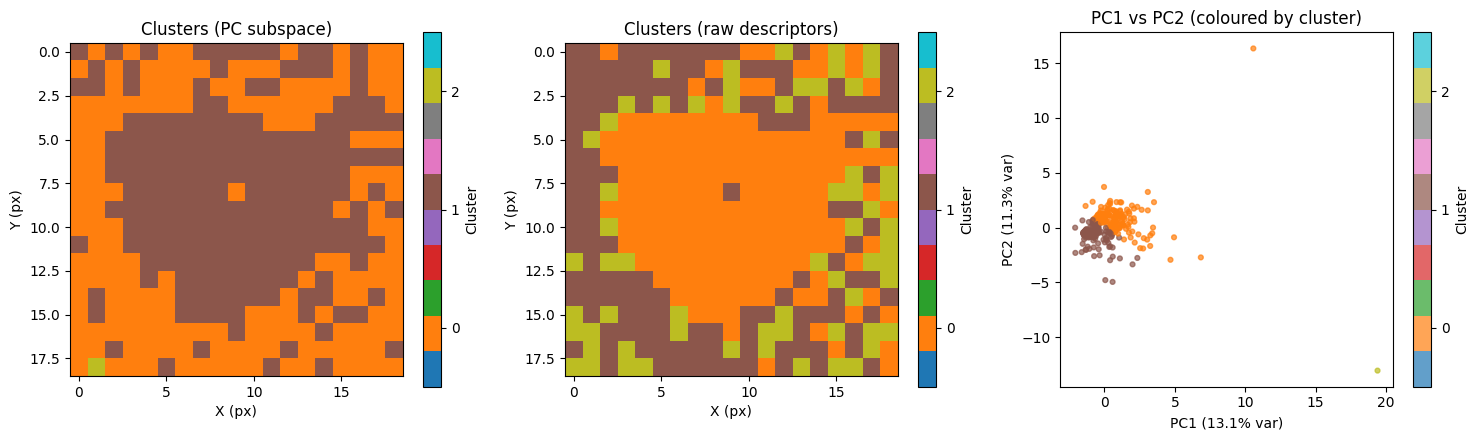

In [20]:
cmap_discrete = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ---- 2-D cluster maps ----
for ax, df_clus, title in [
    (axes[0], df_a, "Clusters (PC subspace)"),
    (axes[1], df_b, "Clusters (raw descriptors)"),
]:
    cluster_map = df_clus.pivot(
        index="y", columns="x", values="cluster"
    ).to_numpy(dtype=float)
    im = ax.imshow(
        cluster_map, cmap=cmap_discrete, origin="upper",
        vmin=-0.5, vmax=2.5, interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xlabel("X (px)")
    ax.set_ylabel("Y (px)")
    plt.colorbar(im, ax=ax, ticks=[0, 1, 2], label="Cluster")

# ---- PC scatter coloured by Variant-A cluster ----
ax = axes[2]
valid = df_a[df_a["cluster"].notna()]
scatter = ax.scatter(
    valid["pc1"], valid["pc2"],
    c=valid["cluster"].astype(int),
    cmap=cmap_discrete, vmin=-0.5, vmax=2.5,
    s=12, alpha=0.7,
)
ax.set_xlabel(f"PC1 ({evr[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({evr[1]:.1%} var)")
ax.set_title("PC1 vs PC2 (coloured by cluster)")
plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2], label="Cluster")

plt.tight_layout()
plt.show()

## 6 · Interpretation and notes

The three clusters correspond to spatially coherent regions in the map.
Reading off the centroid positions in descriptor space may reveal, for example:

- Regions where WS₂ or MoS₂ peaks dominate (peak height ratios differ between clusters).
- Regions with shifted peak positions (possible strain or doping variations).
- Edge versus interior regions of the flake (often captured by PC1).

**Interpretability reminder.**  Cluster labels are assigned by k-means on descriptor distances;
they do not directly map to material phases or compositions without domain-specific validation.
This tool is for exploratory discovery only — no claim of automatic material identification
is made.

For further reading, see the `ramanpl.ml.clustering` API reference and the
[user guide section on clustering](../../docs/source/user-guide/clustering.md).